# Εργασία - Αναγνώριση Προτύπων & Μηχανική Μάθηση 2025-2026

Μανωλίδου Ανατολή 10874 amanolid@ece.auth.gr  
Σκλαβενίτης Γεώργιος 10708 gsklaven@ece.auth.gr



Σε αυτό το μέρος θα εργαστείτε με το datasetTV.csv το οποίο θα χρησιμοποιήσετε ως training set. Τα training
δεδομένα σας έχουν 8743 δείγματα και 224 χαρακτηριστικά (features) ανα δείγμα (sample) που συνοδεύονται από
μια ετικέτα (label), 1, ..., 5 στην τελευταία στήλη. Με αυτά τα δεδομένα αναπτύξτε ένα αλγόριθμό ταξινόμησης
με όποια μέθοδο εσείς επιθυμείτε. Μπορείτε επίσης να διαχειριστείτε τις τιμές των χαρακτηριστικών σας όπως
νομίζετε.

Ακολούθως θα χρησιμοποιήσετε τα δεδομένα του αρχείου datasetTest.csv (6955 δείγματα) σαν test set (σε
αυτό δεν δίνονται οι ετικέτες). Σε αυτά τα δεδομένα θα εφαρμόσετε το τελικό, εκπαιδευμένο μοντέλο σας
και θα εξάγετε ένα διάνυσμα με το όνομα labelsX το οποίο
και θα υποβάλετε σε numpy μορφή.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


## Περιγραφή του dataset

In [2]:
train_data = pd.read_csv('/kaggle/input/projectdatasets/datasetTV.csv', sep=',', header=None) # 'header=None' indicates that the file does not contain a header row


test_data = pd.read_csv('/kaggle/input/projectdatasets/datasetTest.csv', header=None)

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8743 entries, 0 to 8742
Columns: 225 entries, 0 to 224
dtypes: float64(224), int64(1)
memory usage: 15.0 MB


In [4]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6955 entries, 0 to 6954
Columns: 224 entries, 0 to 223
dtypes: float64(224)
memory usage: 11.9 MB


Class Distribution (Labels):
224
1    1769
2    1720
3    1754
4    1716
5    1784
Name: count, dtype: int64


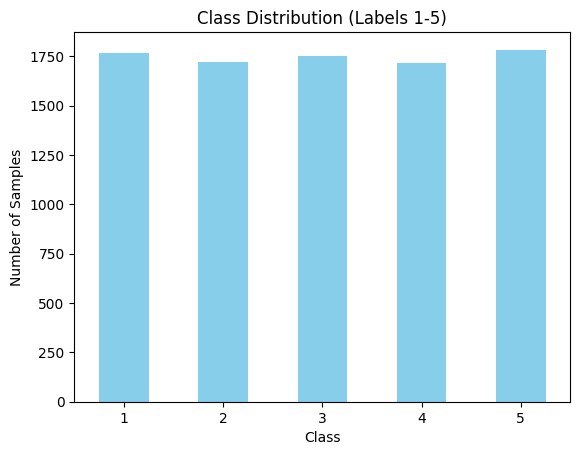

In [5]:
# Check for class imbalance

print("Class Distribution (Labels):")
print(train_data.iloc[:, -1].value_counts().sort_index())

train_data.iloc[:, -1].value_counts().sort_index().plot(kind='bar', rot=0, color='skyblue')
plt.title('Class Distribution (Labels 1-5)')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

Δεν φαίνεται να έχουμε προβλήματα class imbalance, οπότε δεν χρειάζεται διόρθωση σε αυτό το κομμάτι

In [6]:
# Separate features (X) and labels (y) from the training data

X = train_data.iloc[:, :-1].values
y = train_data.iloc[:, -1].values

In [7]:
print(train_data.iloc[:, :5].describe())

                 0            1            2            3            4
count  8743.000000  8743.000000  8743.000000  8743.000000  8743.000000
mean      0.360086     0.001636     0.343860     0.177411     0.199805
std       0.545784     0.321264     0.537970     0.479141     0.469726
min      -1.052900    -1.492000    -1.168500    -1.154900    -1.238800
25%      -0.056065    -0.212760    -0.059468    -0.154845    -0.121140
50%       0.273600     0.004490     0.254900     0.102000     0.126890
75%       0.772390     0.212595     0.739950     0.428225     0.449460
max       2.035000     1.582200     2.075400     1.928000     1.934200


## Γενικές Συναρτήσεις

In [8]:
# Function to evaluate a classification model and display various metrics and a confusion matrix

def evaluate(y_true, y_pred, model_name="Model"):
    print(f"\n Evaluation: {model_name}")

    # Calculate various classification metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")

    # Print the calculated metrics
    print(f" Accuracy:  {acc*100:.2f}%")
    print(f" Precision: {prec*100:.2f}%")
    print(f" Recall:    {rec*100:.2f}%")
    print(f" F1 Score:  {f1*100:.2f}%")

    # Print a detailed classification report
    print("\nDetailed Report:")
    print(classification_report(y_true, y_pred))

    # Plot the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc

In [9]:
# Function to tune a machine learning model using GridSearchCV

def tune_model(model, param_grid, X_train, y_train, X_test, y_test, model_name="Unknown", n_jobs_grid=1):
    print(f"Starting Grid Search for: {model_name}...")

    # Set up StratifiedKFold for cross-validation to maintain class distribution
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Initialize GridSearchCV with the model, parameter grid, cross-validation strategy, and scoring metric
    grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy', n_jobs=n_jobs_grid, verbose=1)
    grid_search.fit(X_train, y_train)

    print(f"\n Best Parameters: {grid_search.best_params_}")

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test) # Make predictions on the test set using the best model

    acc = evaluate(y_test, y_pred, model_name) # Evaluate the best model's performance

    return best_model, acc

## Tests

Μπορούμε να χωρίσουμε τα δεδομένα σε training και evaluation, (85% και 15%) για να πάρουμε μια μετρική για τα μοντέλα μας και μετά να εκπαιδεύσουμε το καλύτερο μοντέλο στο συνολικό training dataset.

In [10]:
# Scaling using RobustScaler: uses statistics that are robust to outliers.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# PCA to reduce dimensionality while retaining 99% of variance
pca = PCA(n_components=0.99, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensions before PCA: {X.shape}, After PCA: {X_pca.shape}")

# Labels need to be 0-4 for XGBoost
y_encoded = y - 1

# Split into training (85%) and validation (15%) sets
X_train, X_val, y_train, y_val = train_test_split(X_pca, y_encoded, test_size=0.15, stratify=y_encoded, random_state=42) # stratify=y_encoded ensures that the class distribution is maintained in both sets

Dimensions before PCA: (8743, 224), After PCA: (8743, 215)


Ξεκινάμε να δοκιμάζουμε διάφορες υπερπαραμέτρους για τα γνωστά μοντέλα μας, προκειμένου να δούμε ποια εμφανίζουν τις καλύτερες μετρικές

In [11]:
# Dictionary to store the accuracy results of different models for comparison
results = {}

Starting Grid Search for: Random Forest...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

 Best Parameters: {'class_weight': 'balanced', 'max_depth': 20, 'n_estimators': 500}

 Evaluation: Random Forest
 Accuracy:  78.12%
 Precision: 78.26%
 Recall:    78.06%
 F1 Score:  77.90%

Detailed Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       265
           1       0.67      0.57      0.62       258
           2       0.89      0.81      0.84       263
           3       0.86      0.83      0.84       258
           4       0.64      0.72      0.68       268

    accuracy                           0.78      1312
   macro avg       0.78      0.78      0.78      1312
weighted avg       0.78      0.78      0.78      1312



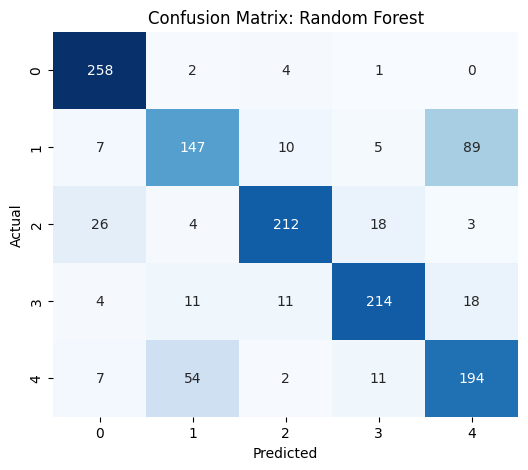

In [12]:
# Random Forest
param_grid_rf = {
    'n_estimators': [100, 300, 500],        # Number of trees in the forest
    'max_depth': [10, 20],                  # Maximum depth of the tree
    'class_weight': ['balanced'],           # Weights associated with classes for 'balanced' mode
}

rf_model, rf_acc = tune_model(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, X_train, y_train, X_val, y_val, "Random Forest", n_jobs_grid=-1
)

results['Random Forest'] = rf_acc

Starting Grid Search for: SVM...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

 Evaluation: SVM
 Accuracy:  85.90%
 Precision: 85.85%
 Recall:    85.87%
 F1 Score:  85.82%

Detailed Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       265
           1       0.76      0.71      0.73       258
           2       0.91      0.92      0.92       263
           3       0.93      0.90      0.92       258
           4       0.74      0.78      0.76       268

    accuracy                           0.86      1312
   macro avg       0.86      0.86      0.86      1312
weighted avg       0.86      0.86      0.86      1312



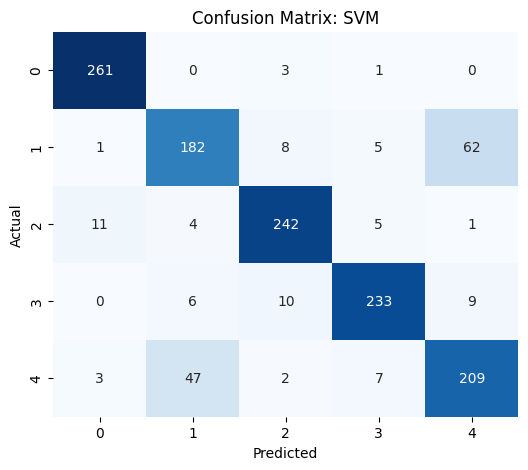

In [13]:
# SVM
param_grid_svm = {
    'C': [0.1, 1, 10],              # Regularization parameter. The strength of the regularization is inversely proportional to C.
    'kernel': ['linear', 'rbf'],    # Specifies the kernel type to be used in the algorithm.
    'gamma': ['scale', 'auto']      # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
}

svm_model, svm_acc = tune_model(
    SVC(probability=True, random_state=42), # Initialize SVC. probability=True is needed for StackingClassifier.
    param_grid_svm, X_train, y_train, X_val, y_val, "SVM", n_jobs_grid=-1
)

results['SVM'] = svm_acc

Starting Grid Search for: XGBoost...
Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [22:36:09] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



 Best Parameters: {'colsample_bytree': 0.85, 'gamma': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 800, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.8}

 Evaluation: XGBoost
 Accuracy:  82.09%
 Precision: 82.24%
 Recall:    82.04%
 F1 Score:  82.03%

Detailed Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       265
           1       0.72      0.65      0.68       258
           2       0.90      0.85      0.87       263
           3       0.87      0.87      0.87       258
           4       0.68      0.76      0.72       268

    accuracy                           0.82      1312
   macro avg       0.82      0.82      0.82      1312
weighted avg       0.82      0.82      0.82      1312



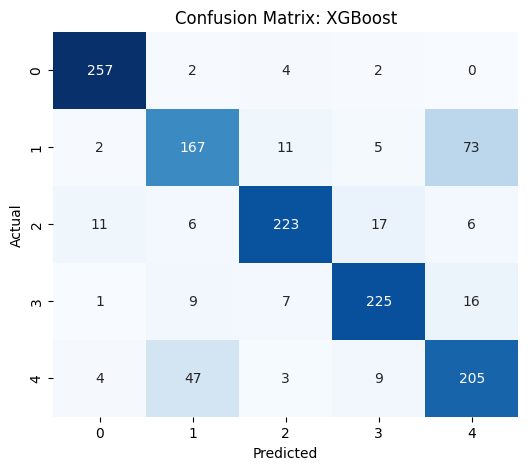

In [14]:
# XGBoost
param_grid_xgb = {
    'n_estimators': [600, 800],                      # Number of boosting rounds (trees)
    'learning_rate': [0.05, 0.1],              # Step size shrinkage to prevent overfitting
    'max_depth': [4, 6],                          # Maximum depth of a tree
    'subsample': [0.8, 0.85, 0.9],                         # Subsample ratio of the training instance.
    'gamma': [1.0],                           # Minimum loss reduction required to make a further partition.
    'colsample_bytree': [0.8, 0.85, 0.9],
    'min_child_weight': [3],
    'reg_alpha': [0.1],
    'reg_lambda': [0.1],
}

xgb_model, xgb_acc = tune_model(
    XGBClassifier(tree_method='hist', device='cuda', random_state=42), # Initialize XGBoost Classifier with GPU support
    param_grid_xgb, X_train, y_train, X_val, y_val, "XGBoost", n_jobs_grid=1
)

results['XGBoost'] = xgb_acc

Starting Grid Search for: KNN...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Best Parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}

 Evaluation: KNN
 Accuracy:  80.72%
 Precision: 81.52%
 Recall:    80.57%
 F1 Score:  80.12%

Detailed Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       265
           1       0.73      0.47      0.58       258
           2       0.90      0.88      0.89       263
           3       0.90      0.86      0.88       258
           4       0.63      0.84      0.72       268

    accuracy                           0.81      1312
   macro avg       0.82      0.81      0.80      1312
weighted avg       0.81      0.81      0.80      1312



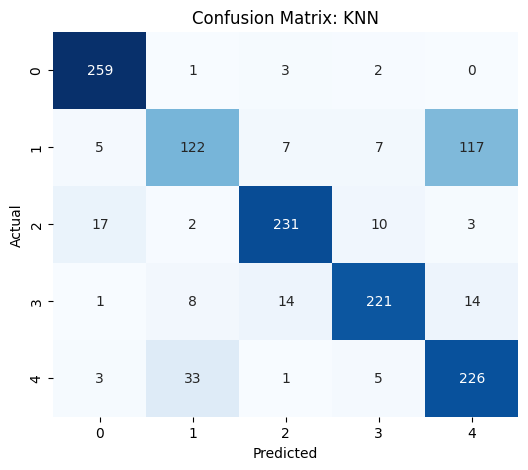

In [15]:
# KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],    # Number of neighbors to use for classification
    'weights': ['uniform', 'distance'], # Weight function used in prediction. 'uniform' (equal weights) or 'distance' (weights by inverse of distance).
    'metric': ['euclidean', 'manhattan'] # Distance metric to use for the tree.
}

best_knn_model, knn_acc = tune_model(
    KNeighborsClassifier(),
    param_grid_knn, X_train, y_train, X_val, y_val, "KNN", n_jobs_grid=-1
)

results['KNN'] = knn_acc

Starting Grid Search for: Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

 Best Parameters: {'C': 0.1, 'max_iter': 2000, 'solver': 'lbfgs'}

 Evaluation: Logistic Regression
 Accuracy:  78.58%
 Precision: 78.46%
 Recall:    78.54%
 F1 Score:  78.43%

Detailed Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       265
           1       0.70      0.62      0.66       258
           2       0.84      0.83      0.83       263
           3       0.82      0.82      0.82       258
           4       0.65      0.70      0.68       268

    accuracy                           0.79      1312
   macro avg       0.78      0.79      0.78      1312
weighted avg       0.78      0.79      0.78      1312



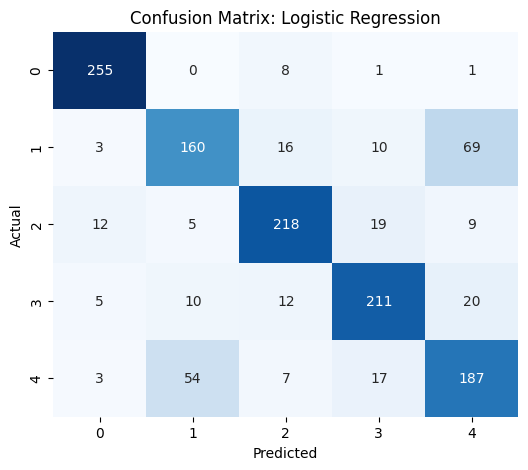

In [16]:
# Logistic Regression
param_grid_log = {
    'C': [0.1, 1, 10, 100],         # Inverse of regularization strength; must be a positive float.
    'solver': ['liblinear', 'lbfgs'], # Algorithm to use in the optimization problem. 'liblinear' for small datasets, 'lbfgs' for larger ones.
    'max_iter': [2000]              # Maximum number of iterations taken for the solvers to converge.
}


best_log_model, log_acc = tune_model(
    LogisticRegression(random_state=42),
    param_grid_log, X_train, y_train, X_val, y_val, "Logistic Regression", n_jobs_grid=-1
)

results['Logistic Regression'] = log_acc

Μπορούμε να δημιουργήσουμε το τελικό μοντέλο, ως συνδυασμό των παραπάνω μετρικών, με χρήση του Stacking

Training Stacking Model


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[22:49:53] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

[22:49:55] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to pr


 Final Accuracy: 86.05%

 Evaluation: Stacking Ensemble
 Accuracy:  86.05%
 Precision: 86.09%
 Recall:    86.01%
 F1 Score:  85.98%

Detailed Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       265
           1       0.77      0.70      0.73       258
           2       0.91      0.93      0.92       263
           3       0.93      0.90      0.91       258
           4       0.74      0.79      0.76       268

    accuracy                           0.86      1312
   macro avg       0.86      0.86      0.86      1312
weighted avg       0.86      0.86      0.86      1312



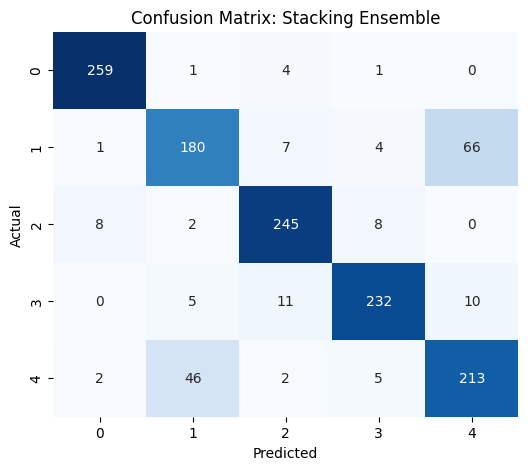

In [17]:
# Stacking Ensemble

# Using the best metrics for every model
estimators = [
    ('xgb1', XGBClassifier(learning_rate = 0.05,
              n_estimators = 800,
              max_depth = 4,
              min_child_weight = 3,
              subsample = 0.8,
              colsample_bytree = 0.85,
              gamma = 1.0,
              reg_alpha = 0.1,
              reg_lambda = 0.1,
              tree_method='hist',
              device='cuda',
              random_state=42)),

    # Extra XGBC layer
    ('xgb2', XGBClassifier(n_estimators=500, learning_rate=0.08, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8,
                           tree_method='hist', device='cuda', random_state=123)),

    ('knn', KNeighborsClassifier(metric = 'euclidean', n_neighbors = 11, weights = 'distance')),

    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20,
                                  min_samples_split=5, class_weight='balanced',
                                  n_jobs=-1, random_state=42)),

    ('svm', SVC(C=10, kernel='rbf', gamma='scale', probability=True,
                class_weight='balanced', random_state=42))
]

# Meta-learner with L2 regularization
meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1, solver = 'lbfgs')

# Stacking with CV=5
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=1
)

print("Training Stacking Model")
stacking_model.fit(X_train, y_train) # Train the stacking model on the training data
final_acc = stacking_model.score(X_val, y_val) # Evaluate the stacking model on the validation data

print(f"\n Final Accuracy: {final_acc*100:.2f}%")

y_pred = stacking_model.predict(X_val) # Get predictions from the stacking model

# Evaluate
stack_acc = evaluate(y_val, y_pred, "Stacking Ensemble")
results['Stacking'] = stack_acc

Ξεκινάμε την διαδικασία από την αρχή, ώστε αυτή τη φορά να χρησιμοποιήσουμε και Feature Selection

In [20]:
# Load training data
train_data = pd.read_csv('/kaggle/input/projectdatasets/datasetTV.csv', header=None)
X = train_data.iloc[:, :-1].values
y = train_data.iloc[:, -1].values

# Load test data
test_data = pd.read_csv('/kaggle/input/projectdatasets/datasetTest.csv', header=None)
X_test = test_data.values

print(f" Training samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f" Test samples: {X_test.shape[0]}")
print(f" Class distribution: {np.bincount(y)}")

y_xgb = y - 1

# Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Feature Selection (keep 150 best features)
selector = SelectKBest(mutual_info_classif, k=150)
X_selected = selector.fit_transform(X_scaled, y_xgb)
X_test_selected = selector.transform(X_test_scaled)

print(f" Features after selection: {X_selected.shape[1]}")

# PCA
pca = PCA(n_components=0.99, random_state=42)
X_pca = pca.fit_transform(X_selected)
X_test_pca = pca.transform(X_test_selected)

print(f" Features after PCA: {X_pca.shape[1]} (from {X_selected.shape[1]})")
print(f" Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

X_train, X_val, y_train, y_val = train_test_split(
    X_pca, y_xgb, test_size=0.15, random_state=42, stratify=y_xgb
)

print(f" Training: {X_train.shape[0]} samples")
print(f" Validation: {X_val.shape[0]} samples")

 Training samples: 8743, Features: 224
 Test samples: 6955
 Class distribution: [   0 1769 1720 1754 1716 1784]
 Features after selection: 150
 Features after PCA: 144 (from 150)
 Explained variance: 0.9901
 Training: 7431 samples
 Validation: 1312 samples


Training Stacking Model


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[22:55:01] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

[22:55:01] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to pr


 Final Accuracy: 88.64%

 Evaluation: Stacking Ensemble
 Accuracy:  88.64%
 Precision: 88.70%
 Recall:    88.60%
 F1 Score:  88.58%

Detailed Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       265
           1       0.82      0.73      0.77       258
           2       0.94      0.95      0.95       263
           3       0.93      0.92      0.93       258
           4       0.77      0.84      0.80       268

    accuracy                           0.89      1312
   macro avg       0.89      0.89      0.89      1312
weighted avg       0.89      0.89      0.89      1312



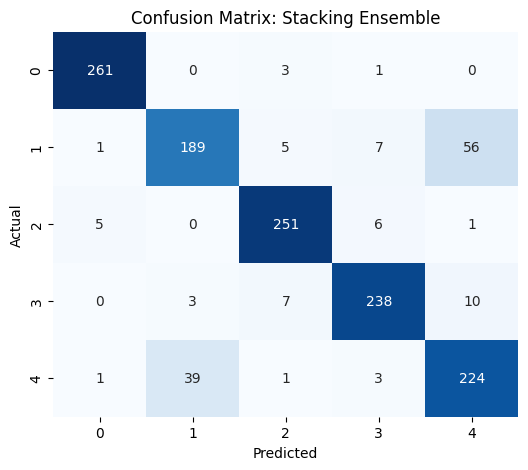

In [21]:
# Stacking Ensemble

estimators = [
    ('xgb1', XGBClassifier(learning_rate = 0.05,
              n_estimators = 800,
              max_depth = 4,
              min_child_weight = 3,
              subsample = 0.8,
              colsample_bytree = 0.85,
              gamma = 1.0,
              reg_alpha = 0.1,
              reg_lambda = 0.1,
              tree_method='hist',
              device='cuda',
              random_state=42)),

    ('xgb2', XGBClassifier(n_estimators=500, learning_rate=0.08, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8,
                           tree_method='hist', device='cuda', random_state=123)),

    ('knn', KNeighborsClassifier(metric = 'euclidean', n_neighbors = 11, weights = 'distance')),

    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20,
                                  min_samples_split=5, class_weight='balanced',
                                  n_jobs=-1, random_state=42)),

    ('svm', SVC(C=10, kernel='rbf', gamma='scale', probability=True,
                class_weight='balanced', random_state=42))
]

# Meta-learner with L2 regularization
meta_model = LogisticRegression(C=1.0, max_iter=2000, random_state=42, n_jobs=-1, solver = 'lbfgs')

# Stacking with CV=5
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=1
)

print("Training Stacking Model")
stacking_model.fit(X_train, y_train) # Train the stacking model on the training data
final_acc = stacking_model.score(X_val, y_val) # Evaluate the stacking model on the validation data

print(f"\n Final Accuracy: {final_acc*100:.2f}%")

y_pred = stacking_model.predict(X_val) # Get predictions from the stacking model

# Evaluate
stack_acc = evaluate(y_val, y_pred, "Stacking Ensemble")
results['Stacking'] = stack_acc

Τώρα μπορούμε να κάνουμε train στο σύνολο των δεδομένων για να έχουμε το καλύτερο δυνατό αποτέλεσμα, χωρίς να σπάσουμε σε training και validation datasets.

In [22]:
# Full Dataset
X_total = np.vstack((X_train, X_val))
y_total = np.concatenate((y_train, y_val))

print(f"Training Data (X_total): {X_total.shape}")
print(f"Training Labels (y_total): {y_total.shape}")
print(f"Test Data (X_test_pca):  {X_test_pca.shape}")

Training Data (X_total): (8743, 144)
Training Labels (y_total): (8743,)
Test Data (X_test_pca):  (6955, 144)


Training Final Stacking Model on FULL dataset


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[22:58:50] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.1min finished
[Paral


Final Accuracy on Training Data: 100.00%

 Evaluation: Stacking Ensemble (Validation Set)
 Accuracy:  100.00%
 Precision: 100.00%
 Recall:    100.00%
 F1 Score:  100.00%

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       265
           1       1.00      1.00      1.00       258
           2       1.00      1.00      1.00       263
           3       1.00      1.00      1.00       258
           4       1.00      1.00      1.00       268

    accuracy                           1.00      1312
   macro avg       1.00      1.00      1.00      1312
weighted avg       1.00      1.00      1.00      1312



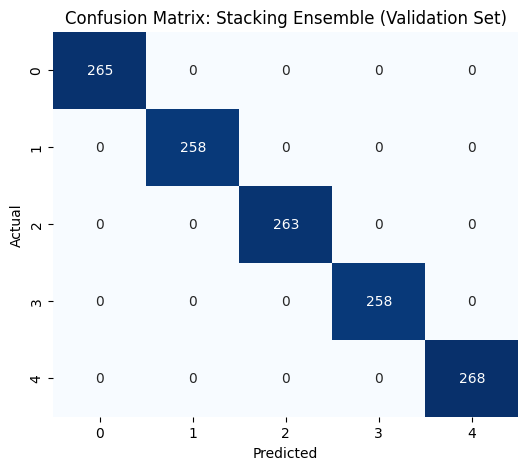

In [23]:
# Stacking Ensemble - FINAL MODEL trained on full dataset

estimators = [
    ('xgb1', XGBClassifier(learning_rate = 0.05,
              n_estimators = 800,
              max_depth = 4,
              min_child_weight = 3,
              subsample = 0.8,
              colsample_bytree = 0.85,
              gamma = 1.0,
              reg_alpha = 0.1,
              reg_lambda = 0.1,
              tree_method='hist',
              device='cuda',
              random_state=42)),

    ('xgb2', XGBClassifier(n_estimators=500, learning_rate=0.08, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8,
                           tree_method='hist', device='cuda', random_state=123)),

    ('knn', KNeighborsClassifier(metric = 'euclidean', n_neighbors = 11, weights = 'distance')),

    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20,
                                  min_samples_split=5, class_weight='balanced',
                                  n_jobs=-1, random_state=42)),

    ('svm', SVC(C=10, kernel='rbf', gamma='scale', probability=True,
                class_weight='balanced', random_state=42))
]

# Meta-learner with L2 regularization
meta_model = LogisticRegression(C=1.0, max_iter=2000, random_state=42, n_jobs=-1, solver = 'lbfgs')

# Stacking with CV=5
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=1
)

print("Training Final Stacking Model on FULL dataset")
stacking_model.fit(X_total, y_total) # Train the stacking model on the FULL training data
final_acc = stacking_model.score(X_total, y_total) # Evaluate the stacking model on the training data

print(f"\nFinal Accuracy on Training Data: {final_acc*100:.2f}%")

y_pred = stacking_model.predict(X_val) # Get predictions from the stacking model for reference

# Evaluate on validation set for reference
stack_acc = evaluate(y_val, y_pred, "Stacking Ensemble (Validation Set)")
results['Stacking'] = stack_acc

In [24]:
# Make predictions on test set
print("\nMaking predictions on test set...")
y_pred_test = stacking_model.predict(X_test_pca)

# Convert from 0-4 (XGBoost encoding) back to 1-5 (original labels)
labelsX = y_pred_test + 1

print(f"\nTest Set Predictions:")
print(f"   Shape: {labelsX.shape}")
print(f"   Unique classes: {np.unique(labelsX)}")
print(f"   Class distribution: {np.bincount(labelsX)}")

# Save as numpy file
np.save('labelsX.npy', labelsX)
print(f"\nSaved predictions to 'labelsX.npy'")
print(f"Sample predictions (first 20): {labelsX[:20]}")

# Verify labelsX is in numpy format
print(f"\nlabelsX type: {type(labelsX)}")
print(f"labelsX dtype: {labelsX.dtype}")


Making predictions on test set...

Test Set Predictions:
   Shape: (6955,)
   Unique classes: [1 2 3 4 5]
   Class distribution: [   0 1381 1314 1436 1322 1502]

Saved predictions to 'labelsX.npy'
Sample predictions (first 20): [1 4 5 2 5 4 5 5 1 3 2 3 5 1 2 3 5 2 2 3]

labelsX type: <class 'numpy.ndarray'>
labelsX dtype: int64


In [26]:
# Verify that labelsX.npy was saved correctly

# Load the saved numpy file
loaded_labels = np.load('labelsX.npy')

print(f"\n Successfully loaded 'labelsX.npy' using np.load()")
print(f"\nFile Properties:")
print(f"   Shape: {loaded_labels.shape}")
print(f"   Expected shape: ({X_test_pca.shape[0]},)")
print(f"   Match: {loaded_labels.shape[0] == X_test_pca.shape[0]}")
print(f"\n   Data type: {loaded_labels.dtype}")
print(f"   Data type is integer: {np.issubdtype(loaded_labels.dtype, np.integer)}")

print(f"\nClass Information:")
print(f"   Unique classes: {np.unique(loaded_labels)}")
print(f"   Expected range: [1, 2, 3, 4, 5]")
print(f"   All classes in range [1-5]: {np.all((loaded_labels >= 1) & (loaded_labels <= 5))}")

print(f"\nClass Distribution:")
unique, counts = np.unique(loaded_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"   Class {label}: {count} samples ({count/len(loaded_labels)*100:.2f}%)")

print(f"\nSample Predictions (first 30):")
print(loaded_labels[:30])

print(f"\n All checks passed! labelsX.npy is correctly formatted.")
print("="*60)


 Successfully loaded 'labelsX.npy' using np.load()

File Properties:
   Shape: (6955,)
   Expected shape: (6955,)
   Match: True

   Data type: int64
   Data type is integer: True

Class Information:
   Unique classes: [1 2 3 4 5]
   Expected range: [1, 2, 3, 4, 5]
   All classes in range [1-5]: True

Class Distribution:
   Class 1: 1381 samples (19.86%)
   Class 2: 1314 samples (18.89%)
   Class 3: 1436 samples (20.65%)
   Class 4: 1322 samples (19.01%)
   Class 5: 1502 samples (21.60%)

Sample Predictions (first 30):
[1 4 5 2 5 4 5 5 1 3 2 3 5 1 2 3 5 2 2 3 4 5 5 4 5 5 2 3 5 3]

 All checks passed! labelsX.npy is correctly formatted.
